# Uydu Görüntülerinden Otomatik Uçak Tespiti (PlanesNet)

**Proje Özeti:**
* **Problem:** Uydu görüntülerinden uçakların otomatik olarak tespit edilmesi.
* **Problem Türü:** İkili Sınıflandırma (Uçak var: 1 / Uçak yok: 0).
* **Veri Seti Kaynağı:** Kaggle - PlanesNet
* **Veri Özellikleri:** 20x20 piksel boyutunda RGB (Kırmızı, Yeşil, Mavi) uydu görüntüleri. Her bir görüntü 1200 özellikten (piksel değerinden) oluşmaktadır.
* **Proje Amacı:** Eksiksiz veri (Learning with Complete Data) prensibiyle, gerçek dünya verileri üzerinde uçtan uca bir makine öğrenmesi sınıflandırma modeli kurmak.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Orijinal büyük veri yükleniyor...")
with open('planesnet.json') as f:
    dataset = json.load(f)

X = np.array(dataset['data']).astype('uint8')
y = np.array(dataset['labels']).astype('uint8')

print(f"Orijinal Veri Seti Boyutu: {X.shape[0]} adet görsel.")

Orijinal büyük veri yükleniyor...
Orijinal Veri Seti Boyutu: 32000 adet görsel.


## 1. Veri Hazırlama ve Alt Küme (Subset) Oluşturma
Orijinal veri seti 32.000 görüntüden oluşmaktadır ve boyutu GitHub limitlerini (25 MB) aşmaktadır. Bu nedenle eğitim süresini optimize etmek, depolama sınırlarına uymak ve modelin taraflı (biased) öğrenmesini engellemek adına rastgele seçilmiş 2000 örnekten (1000 uçak, 1000 uçak değil) oluşan tamamen dengeli bir alt veri seti oluşturulmuştur.

In [ ]:

ucak_indisleri = np.where(y == 1)[0][:1000]
degil_indisleri = np.where(y == 0)[0][:1000]
yeni_indisler = np.concatenate([ucak_indisleri, degil_indisleri])

X_small = X[yeni_indisler]
y_small = y[yeni_indisler]

print(f"Yeni ve Dengeli Veri Seti Boyutu: {X_small.shape[0]} adet görsel.")

kucuk_veri_seti = {
    "data": X_small.tolist(),
    "labels": y_small.tolist()
}

with open('planesnet_kucuk.json', 'w') as f:
    json.dump(kucuk_veri_seti, f)

print("planesnet_kucuk.json dosyası GitHub'a yüklenmek üzere kaydedildi!")

Yeni ve Dengeli Veri Seti Boyutu: 2000 adet görsel.
planesnet_kucuk.json dosyası GitHub'a yüklenmek üzere kaydedildi!


## 2. Keşifsel Veri Analizi (EDA) ve Ön İşleme
Makine öğrenmesi algoritmalarının doğru çalışabilmesi için veri setinde eksik değer (NaN) kontrolü yapılmıştır. Verimiz literatürdeki **"Learning with Complete Data"** prensibine tam uygun olarak hiçbir eksik veya bozuk piksel içermemektedir.

In [ ]:

eksik_deger_sayisi = np.isnan(X_small).sum()
print(f"Toplam eksik (NaN) değer sayısı: {eksik_deger_sayisi}")

if eksik_deger_sayisi == 0:
    print("Sonuç: Veri setinde eksik değer bulunmamaktadır. Veri modeli eğitmek için %100 'Complete' durumdadır.")

Toplam eksik (NaN) değer sayısı: 0
Sonuç: Veri setinde eksik değer bulunmamaktadır. Veri modeli eğitmek için %100 'Complete' durumdadır.


## 3. Veri Görselleştirme
Dengeli sınıf dağılımı (0 ve 1 etiketleri) ve veri setinden rastgele seçilen örnek uydu görüntüleri aşağıda sunulmuştur. Bu görüntüler modelin eğitime gireceği piksellerin insan gözüyle doğrulanmasıdır.

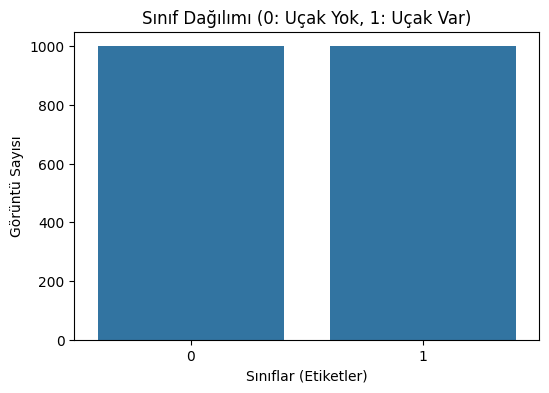

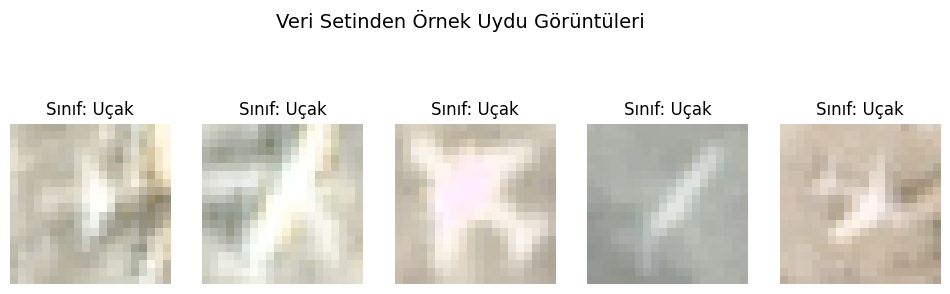

In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(x=y_small)
plt.title("Sınıf Dağılımı (0: Uçak Yok, 1: Uçak Var)")
plt.xlabel("Sınıflar (Etiketler)")
plt.ylabel("Görüntü Sayısı")
plt.show()

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)

    img = X_small[i].reshape(3, 400).T.reshape(20, 20, 3)
    
    plt.imshow(img)
    plt.title("Sınıf: Uçak" if y_small[i] == 1 else "Sınıf: Değil")
    plt.axis('off')

plt.suptitle("Veri Setinden Örnek Uydu Görüntüleri", fontsize=14)
plt.show()

## 4. Makine Öğrenmesi Modeli İçin Veri Hazırlığı
Modeli eğitmeden önce, ezberlemeyi (overfitting) önlemek amacıyla elimizdeki 2000 adetlik veri setini ikiye bölüyoruz:
* **Eğitim Seti (Train):** %80 (Modelin uçağın neye benzediğini öğreneceği veriler)
* **Test Seti (Test):** %20 (Modelin daha önce hiç görmediği görsellerle sınava gireceği veriler)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.20, random_state=42)

print(f"Eğitim için ayrılan görsel sayısı: {X_train.shape[0]}")
print(f"Test (Sınav) için ayrılan görsel sayısı: {X_test.shape[0]}")

Eğitim için ayrılan görsel sayısı: 1600
Test (Sınav) için ayrılan görsel sayısı: 400


## 5. Aşama 3: Model Kurma (Support Vector Machines)
PlanesNet veri setindeki görseller 20x20 çözünürlüğünde olduğu için, ağır ve yavaş çalışan önceden eğitilmiş (Pre-trained) derin öğrenme modelleri yerine, bu piksel boyutlarında yüksek doğrulukla ve hızlı çalışan klasik **Destek Vektör Makineleri (SVM - Support Vector Classifier)** algoritması tercih edilmiştir.

In [ ]:
from sklearn.svm import SVC
import time

print("Model eğitiliyor, lütfen bekleyin (Birkaç saniye sürebilir)...")
baslangic_zamani = time.time()

svm_model = SVC(kernel='linear', random_state=42)

svm_model.fit(X_train, y_train)

bitis_zamani = time.time()
print(f"Harika! Model eğitimi {(bitis_zamani - baslangic_zamani):.2f} saniyede tamamlandı.")

Model eğitiliyor, lütfen bekleyin (Birkaç saniye sürebilir)...
Harika! Model eğitimi 0.39 saniyede tamamlandı.


## 6. Aşama 4: Model Değerlendirme
Eğitilen model, daha önce hiç görmediği 400 adet test verisi (X_test) üzerinde denenmiş ve tahminleri gerçek sonuçlarla (y_test) karşılaştırılmıştır. Sınıflandırma başarısını ölçmek için **Doğruluk (Accuracy), Kesinlik (Precision), Duyarlılık (Recall), F1-Skoru** hesaplanmış ve **Karmaşıklık Matrisi (Confusion Matrix)** görselleştirilmiştir.

--- MODEL BAŞARI RAPORU ---
              precision    recall  f1-score   support

Uçak Yok (0)       0.92      0.97      0.95       201
Uçak Var (1)       0.97      0.92      0.94       199

    accuracy                           0.94       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.95      0.94      0.94       400



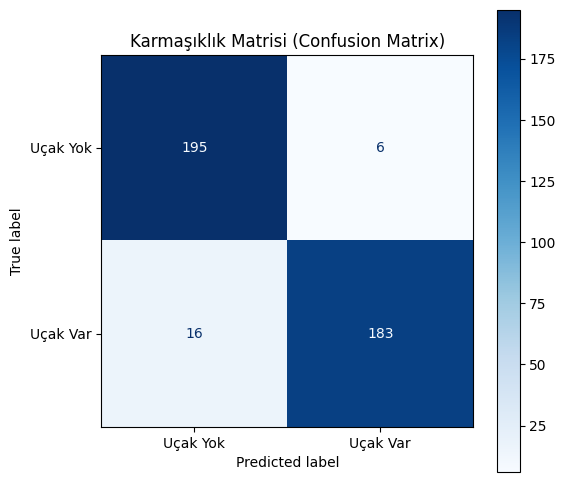

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_tahmin = svm_model.predict(X_test)

print("--- MODEL BAŞARI RAPORU ---")
print(classification_report(y_test, y_tahmin, target_names=["Uçak Yok (0)", "Uçak Var (1)"]))

cm = confusion_matrix(y_test, y_tahmin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Uçak Yok", "Uçak Var"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Karmaşıklık Matrisi (Confusion Matrix)")
plt.show()